# Get Packages

In [68]:
import yfinance as yf
import polars as pl
import numpy as np
import matplotlib.pyplot as plt

# Read in needed packages

In [69]:
# We use SPY as our equity index and TLT as our bond index
tickers = ["SPY", "TLT"]

# Read in data from yFinance (TLT starts in 2002-07-30)
data = (
    yf.download(tickers, start="2002-07-30", end="2025-10-05", auto_adjust=True)["Close"]
    .dropna()
)

# Convert to Polars
df = pl.from_pandas(data.reset_index())
df = df.rename({"Date": "date", "SPY": "SPY", "TLT": "TLT"}).sort("date")

# Compute daily returns
returns = df.with_columns([
    (pl.col("SPY") / pl.col("SPY").shift(1) - 1).alias("r_spy"),
    (pl.col("TLT") / pl.col("TLT").shift(1) - 1).alias("r_tlt"),
]).drop_nulls()

returns

[*********************100%***********************]  2 of 2 completed


date,SPY,TLT,r_spy,r_tlt
datetime[ns],f64,f64,f64,f64
2002-07-31 00:00:00,59.320904,37.514793,0.002419,0.01239
2002-08-01 00:00:00,57.77211,37.728443,-0.026109,0.005695
2002-08-02 00:00:00,56.47715,38.114799,-0.022415,0.01024
2002-08-05 00:00:00,54.511974,38.282978,-0.034796,0.004412
2002-08-06 00:00:00,56.347061,37.9557,0.033664,-0.008549
…,…,…,…,…
2025-09-29 00:00:00,663.679993,89.319092,0.00281,0.008211
2025-09-30 00:00:00,666.179993,89.059998,0.003767,-0.002901
2025-10-01 00:00:00,668.450012,89.290001,0.003408,0.002583


# Compute Strategy

In [70]:
# Calc sharpe ratio 
def sharpe_ratio(series, trading_days=252):
    mean = series.mean()
    std = series.std()
    return (mean / std) * np.sqrt(trading_days) if std > 0 else np.nan

In [71]:
# Get year and month grouping
grouped = returns.with_columns([
    pl.col("date").dt.year().alias("year"),
    pl.col("date").dt.month().alias("month"),
])

strategy_ls = []   # long-short
strategy_lo = []   # long-only

# Group by and go month by month
for (yr, mo), g in grouped.group_by(["year", "month"], maintain_order=True):
    g = g.sort("date")
    if g.height < 15:
        continue

    # First 15 trading days performance
    spy_ret_15 = g["r_spy"][:15].log1p().sum()
    tlt_ret_15 = g["r_tlt"][:15].log1p().sum()

    # Determine winner/loser
    if spy_ret_15 > tlt_ret_15:
        loser, winner = "r_tlt", "r_spy"
    else:
        loser, winner = "r_spy", "r_tlt"

    # Remaining days (day 16 onward)
    trade = g.slice(15, g.height - 15)
    if trade.height == 0:
        continue

    # Long-short (dollar neutral)
    trade_ls = (
        0.5 * trade[loser] - 0.5 * trade[winner]
    )

    # Long-only (only trade the loser/underperformer)
    trade_lo = trade[loser]

    strategy_ls.append(pl.DataFrame({"date": trade["date"], "r_strat": trade_ls}))
    strategy_lo.append(pl.DataFrame({"date": trade["date"], "r_strat": trade_lo}))

# Combine
strat_ls = pl.concat(strategy_ls).rename({"r_strat": "r_strat_ls"})
strat_lo = pl.concat(strategy_lo).rename({"r_strat": "r_strat_lo"})

In [72]:
# Merge into the main dataframe
finalRet = (
    grouped.join(strat_ls, on="date", how="left")
      .join(strat_lo, on="date", how="left")
)

# Calc cumulative log returns
for col in ["r_spy", "r_tlt", "r_strat_ls", "r_strat_lo"]:
    finalRet = finalRet.with_columns(
        (pl.col(col).log1p().cum_sum()).alias(f"cum_{col}")
    )

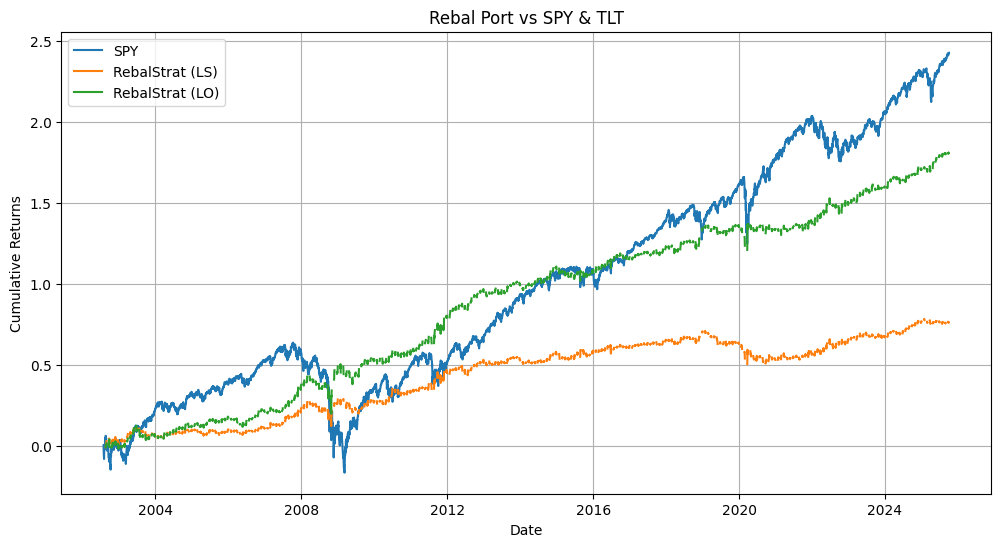

In [73]:
# --- Plotting ---
plt.figure(figsize=(12,6))
plt.plot(finalRet["date"], finalRet["cum_r_spy"], label="SPY")
# plt.plot(finalRet["date"], finalRet["cum_r_tlt"], label="TLT")
plt.plot(finalRet["date"], finalRet["cum_r_strat_ls"], label="RebalStrat (LS)")
plt.plot(finalRet["date"], finalRet["cum_r_strat_lo"], label="RebalStrat (LO)")
plt.legend()
plt.title("Rebal Port vs SPY & TLT")
plt.xlabel("Date")
plt.ylabel("Cumulative Returns")
plt.grid(True)
plt.show()

In [74]:
# Calc sharpe ratio
sharpe = {
    "SPY": round(sharpe_ratio(finalRet["r_spy"].to_numpy()), 3),
    "TLT": round(sharpe_ratio(finalRet["r_tlt"].to_numpy()), 3),
    "Long-Short": round(sharpe_ratio(finalRet["r_strat_ls"].fill_null(0).to_numpy()), 3),
    "Long-Only": round(sharpe_ratio(finalRet["r_strat_lo"].fill_null(0).to_numpy()), 3),
}

sharpe

{'SPY': np.float64(0.648),
 'TLT': np.float64(0.336),
 'Long-Short': np.float64(0.521),
 'Long-Only': np.float64(0.892)}

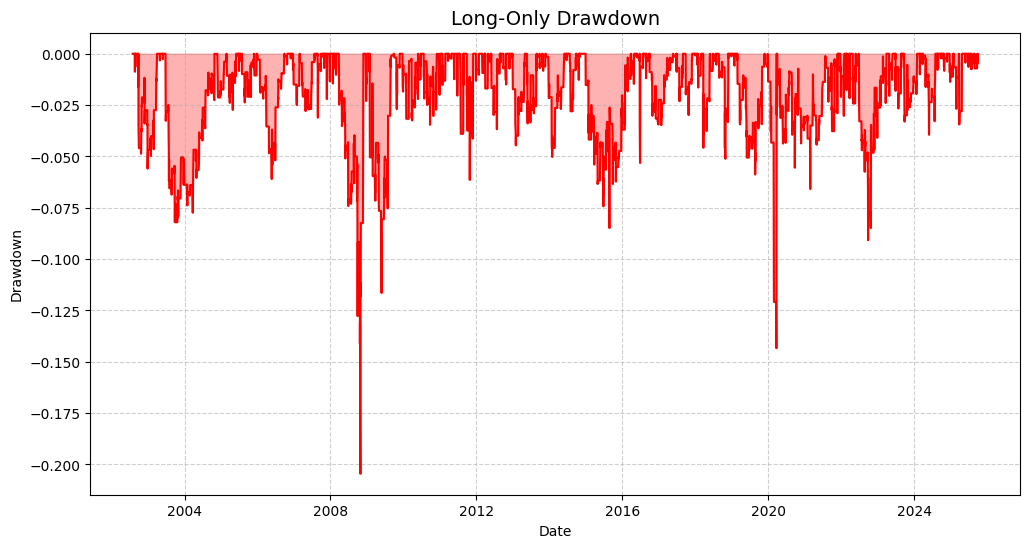

In [75]:
r_lo = finalRet["r_strat_lo"].to_numpy()

# Turn NaNs to 0
r_lo = np.nan_to_num(r_lo, nan=0.0)

# Calculate drawdown
cum_lo = np.cumprod(r_lo + 1)
prevpeak_lo = np.maximum.accumulate(cum_lo)
drawdown_lo = (cum_lo - prevpeak_lo) / prevpeak_lo

plt.figure(figsize=(12,6))
plt.plot(finalRet["date"].to_numpy(), drawdown_lo, color='red', linewidth=1.5)
plt.fill_between(finalRet["date"].to_numpy(), drawdown_lo, 0, color='red', alpha=0.3)
plt.title("Long-Only Drawdown", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

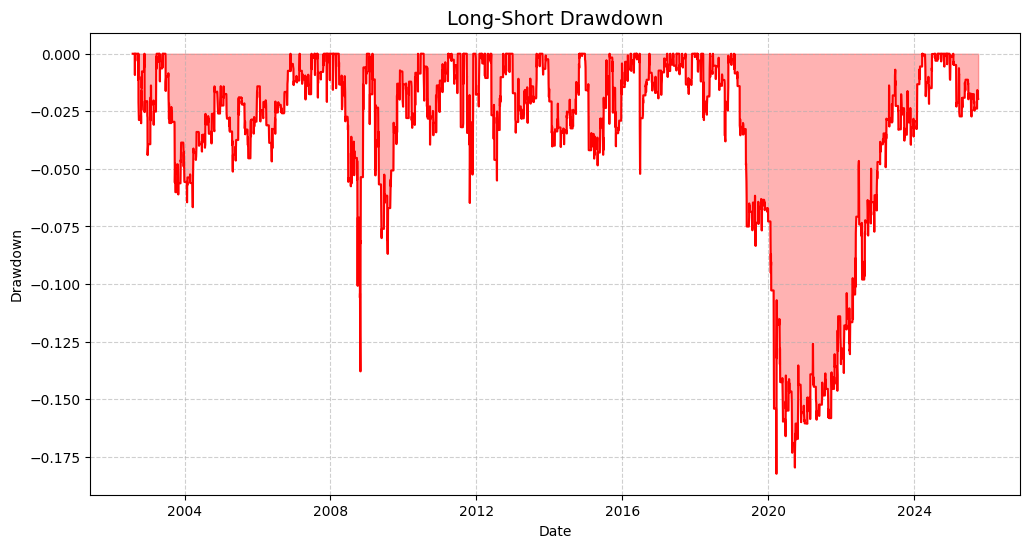

In [76]:
r_ls = finalRet["r_strat_ls"].to_numpy()

# Turn NaNs to 0
r_ls = np.nan_to_num(r_ls, nan=0.0)

# Calculate drawdown
cum_ls = np.cumprod(r_ls + 1)
prevpeak_ls = np.maximum.accumulate(cum_ls)
drawdown_ls = (cum_ls - prevpeak_ls) / prevpeak_ls

plt.figure(figsize=(12,6))
plt.plot(finalRet["date"].to_numpy(), drawdown_ls, color='red', linewidth=1.5)
plt.fill_between(finalRet["date"].to_numpy(), drawdown_ls, 0, color='red', alpha=0.3)
plt.title("Long-Short Drawdown", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()